# Session 3: Data Exploration, Preprocessing, and Quality

⚠️ <span style="color: orange;">Please note we are currently reworking the lecture and still preparing the course materials. You will find this message wherever the course materials are being updated / not finalized.</span> ⚠️

In [2]:
# !uv add pyod matplotlib pandas ydata_profiling numpy scikit-learn tab_err great_expectations openml

Resolved 173 packages in 698ms                                       
Prepared 14 packages in 7.73s                                            
Uninstalled 2 packages in 105ms
Installed 15 packages in 68ms                               
 + dacite==1.9.2
 + filetype==1.2.0
 + imagehash==4.3.2
 - llvmlite==0.47.0
 + llvmlite==0.45.1
 + minify-html==0.18.1
 + multimethod==1.12
 + networkx==3.6.1
 - numba==0.65.0
 + numba==0.62.1
 + phik==0.12.5
 + puremagic==1.30
 + pywavelets==1.9.0
 + typeguard==4.5.1
 + visions==0.8.1
 + wordcloud==1.9.6
 + ydata-profiling==4.18.1


## Learning goals

- Define practical data quality checks
- Address missingness, outliers, and skewed distributions, use taberr for mcar,mnar,mar
- use ydata-profiling for exploratory data analysis / descriptive stats
- define data quality checks with great expectations
- use taberr to test dq tests
- show imputation with sklearn imputer (maybe with different missingness patterns)
- show outlier detection examples
- Understand privacy risks and redaction strategies for LLM-era data workflows, use redakto and redakto examples/results


In [ ]:
## Why Data Quality Matters

- Poor data quality costs the US economy **~$3.1 trillion/year** (IBM, 2016)
- ML models inherit and **amplify** data defects (Sculley et al., 2015 — *Hidden Technical Debt in ML Systems*, NeurIPS)
- GDPR, HIPAA and ISO 8000 mandate **measurable data quality standards**

### The 6 Core Dimensions (Wang & Strong, 1996)

| Dimension | Question |
|---|---|
| **Completeness** | Are all values present? |
| **Uniqueness** | Are records deduplicated? |
| **Consistency** | Do values obey rules/formats? |
| **Accuracy** | Do values reflect reality? |
| **Timeliness** | Is data current enough? |
| **Validity** | Do values match expected domains? |

**TODO** References ISO Standard Data Quality
> Wang, R.Y. & Strong, D.M. (1996). *Beyond Accuracy: What Data Quality Means to Data Consumers*. JMIS, 12(4).

In [1]:
import pandas as pd
import warnings

# create a pandas Series
series_a = pd.Series([0.25, 0.5, 0.75, 1.0])
series_a

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

In [2]:
series_a.index

RangeIndex(start=0, stop=4, step=1)

In [3]:
series_a.values

array([0.25, 0.5 , 0.75, 1.  ])

## Why is this helpful? 

There are many reasons why these indexed structures are helpful. Most of them are related to speed. But many are related to convenience:


In [4]:
fruits = pd.Series([1,0,2,2], index=['apples','oranges','bananas','lemons'])
more_fruits = pd.Series([1,0,1,5], index=['lemons','oranges','apples','bananas'])

fruits + more_fruits

apples     2
bananas    7
lemons     3
oranges    0
dtype: int64

## Applying Arbitrary Functions

In [5]:
# apply custom functions

def some_function(v):
    '''
    Divides number by a million and returns its integer representation
    '''
    return int(v / 1e6)

some_function(35 * 1e6)


35

In [6]:
s = pd.Series(range(int(1e6)))
%timeit s.apply(some_function)

159 ms ± 852 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [7]:
%timeit (s / 1e6).astype(int)

1.53 ms ± 26.5 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Missing Values



There are three main options how to deal with missing values:

- drop rows with missing values
 - probably ok, if you have enough data
 - but can introduce biases in your data that [bias your downstream models](https://ssc.io/publication/fairprep-promoting-data-to-a-first-class-citizen-in-studies-on-fairness-enhancing-interventions-edbt/)
- replace missing values with placeholder symbol
 - probably ok, if you have a nonlinear downstream model and the right type of missingness (MAR or MNAR)
 - but sometimes you are really interested in the missing values
- impute missing values with some ML model
 - [``sklearn``](https://scikit-learn.org/stable/index.html) 
 - [``datawig``](https://datawig.readthedocs.io/en/latest/)



In [22]:
import pandas as pd
import numpy as np

berlin_population_dict = {
 '1945': 2807405,
 '1950': 3336026,
 '1955': None,                         
 '1960': 3274016,
 '1965': np.nan, # pandas understands different missing values                        
 '1970': 3208719}

population_w_nans = pd.Series(berlin_population_dict)
population_w_nans

1945    2807405.0
1950    3336026.0
1955          NaN
1960    3274016.0
1965          NaN
1970    3208719.0
dtype: float64

## Dropping rows

Easy with boolean indexing in pandas or numpy

In [9]:
population_w_nans.isnull()

1945    False
1950    False
1955     True
1960    False
1965     True
1970    False
dtype: bool

In [10]:
population_w_nans[~population_w_nans.isnull()]

1945    2807405.0
1950    3336026.0
1960    3274016.0
1970    3208719.0
dtype: float64

In [11]:
population_w_nans.dropna()

1945    2807405.0
1950    3336026.0
1960    3274016.0
1970    3208719.0
dtype: float64

## Filling with Placeholder


In [12]:
population_w_nans.fillna(method='ffill')

/var/folders/fb/nnrbj09j32jdr_jvd_fnmyn00000gn/T/ipykernel_75445/49778767.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  population_w_nans.fillna(method='ffill')


1945    2807405.0
1950    3336026.0
1955    3336026.0
1960    3274016.0
1965    3274016.0
1970    3208719.0
dtype: float64

In [13]:
population_w_nans.fillna(value=population_w_nans.median())

1945    2807405.0
1950    3336026.0
1955    3241367.5
1960    3274016.0
1965    3241367.5
1970    3208719.0
dtype: float64

## Filling with Placeholder in ``sklearn``

This way you'll be able to replace missing values in ML Pipelines

In [14]:
from sklearn.impute import SimpleImputer
import numpy as np
imp = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imp.fit_transform(population_w_nans.to_numpy().reshape(-1,1))

array([[2807405.],
       [3336026.],
       [2807405.],
       [3274016.],
       [2807405.],
       [3208719.]])

## Imputation

- Imputation of numeric values from other numeric values
- Imputation of categorical values from free text

### Numeric Imputation

We'll use ``datawig`` and ``sklearn``

### Numeric Imputation with ``sklearn`` -- RidgeRegression

In [33]:
# toy data
n = 100
x = np.random.randn(n,1)
y = x**2
df = pd.DataFrame(np.hstack([x,y]),columns=['x','f(x)'])

mask = np.random.random((n,1)) > .9

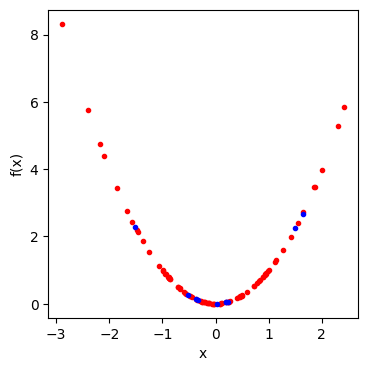

In [35]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pylab as plt

imp = IterativeImputer(max_iter=10, random_state=0)
X_train = df.loc[mask==0,:].values
imp.fit(X_train)

X_test = df.loc[mask>0,:].values
X_test_imputed = imp.transform(X_test)

plt.figure(figsize=[4,4])
plt.plot(X_train[:,0], X_train[:,1], 'r.',
         X_test_imputed[:,0], X_test_imputed[:,1],'b.')
plt.ylabel("f(x)")
plt.xlabel("x");

### Numeric Imputation with ``sklearn`` -- RandomForest

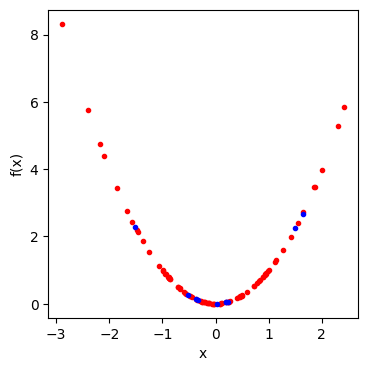

In [36]:
from sklearn.ensemble import RandomForestRegressor
imp = IterativeImputer(estimator=RandomForestRegressor(),
                       max_iter=10, random_state=0)
X_train = df.loc[mask==0,:].values
imp.fit(X_train)

X_test = df.loc[mask>0,:].values
X_test_imputed = imp.transform(X_test)

plt.figure(figsize=[4,4])
plt.plot(X_train[:,0], X_train[:,1], 'r.',
         X_test_imputed[:,0], X_test_imputed[:,1],'b.')
plt.ylabel("f(x)")
plt.xlabel("x");

### Numeric Imputation with ``sklearn`` -- KNN

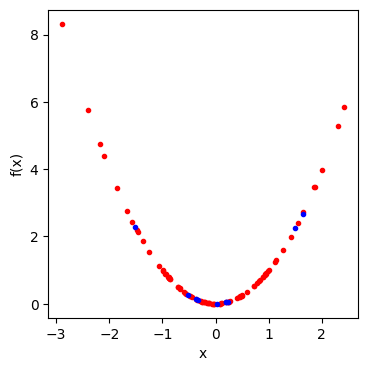

In [37]:
from sklearn.impute import KNNImputer
imp = KNNImputer()

X_train = df.loc[mask==0,:].values
imp.fit(X_train)

X_test = df.loc[mask>0,:].values
X_test_imputed = imp.transform(X_test)

plt.figure(figsize=[4,4])
plt.plot(X_train[:,0], X_train[:,1], 'r.',
         X_test_imputed[:,0], X_test_imputed[:,1],'b.')
plt.ylabel("f(x)")
plt.xlabel("x");

## Preprocessing topics

### Missing data

- Row dropping (simple baseline)
- Placeholder/category imputation
- Model-based imputation
- Compare MCAR, MAR, MNAR assumptions
- taberr example with MCAR, MAR, MNAR

### Distribution imbalance and skew

- Reweighting or resampling
- Stratified splits
- Metric choice aligned to imbalance (e.g., macro-F1)

### Standardizing multimodal data

- Harmonize text/image/tabular metadata keys
- Keep a data dictionary with versioning

## Step 0 — Setup & Sample Dataset

We use a synthetic employee dataset with **intentional defects** for demonstration.

In [2]:
# !pip install pandas ydata-profiling great-expectations -q

import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'employee_id': list(range(1, n + 1)) + [5, 12],          # duplicates
    'name':        ['Alice', 'Bob'] * (n // 2) + [None, 'Bob'],
    'age':         np.random.randint(22, 65, n + 2).tolist(),
    'salary':      np.random.normal(55000, 12000, n + 2).tolist(),
    'department':  np.random.choice(['HR', 'Eng', 'Sales', None], n + 2).tolist(),
    'hire_date':   pd.date_range('2015-01-01', periods=n + 2, freq='W'),
})

# Inject outliers
df.loc[10, 'salary'] = 999_999
df.loc[20, 'age']    = -5

print(f'Shape: {df.shape}')
df.head(3)

Shape: (202, 6)


,employee_id,name,age,salary,department,hire_date
0,1,Alice,60,45378.065880,HR,2015-01-04
1,2,Bob,50,71608.188627,Sales,2015-01-11
2,3,Alice,36,71862.463671,HR,2015-01-18


## Step 1 — Completeness

> *"Completeness: the degree to which all required data is present."*  
> — ISO/IEC 25012 (2008), Data Quality Model

**Metric:**  
$$\text{Completeness}(c) = 1 - \frac{|\text{NULL values in column } c|}{|\text{total rows}|}$$

=== Completeness per column ===
employee_id    1.000
name           0.995
age            1.000
salary         1.000
department     0.767
hire_date      1.000

Overall completeness: 96.04%


In /Users/felix/Nextcloud/nc-beuth/lectures/dsw-2026/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /Users/felix/Nextcloud/nc-beuth/lectures/dsw-2026/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'resetCache' deprecated - use 'reset_cache'


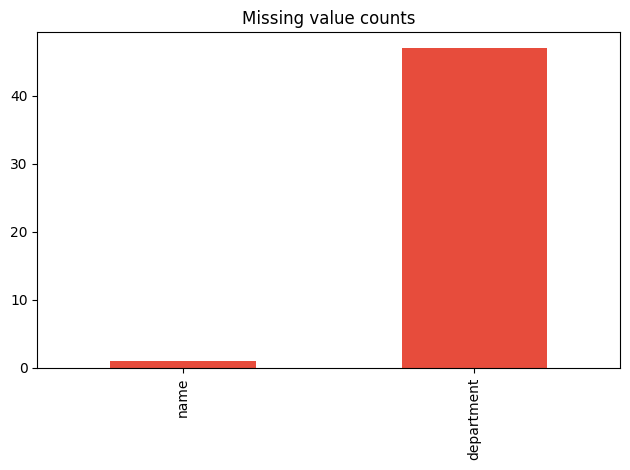

In [3]:
completeness = 1 - df.isnull().mean()

print('=== Completeness per column ===')
print(completeness.round(3).to_string())

print(f'\nOverall completeness: {completeness.mean():.2%}')

# Visualise missing pattern
import matplotlib.pyplot as plt
missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', color='#e74c3c', title='Missing value counts')
plt.tight_layout()
plt.show()

## Step 2 — Uniqueness / Duplicates

Duplicate records inflate model training data and distort statistics (Breck et al., 2017 — *The ML Test Score*, IEEE BigData).

**Metric:**  
$$\text{Uniqueness} = 1 - \frac{|\text{duplicate rows}|}{|\text{total rows}|}$$

In [4]:
n_dupes = df.duplicated(subset='employee_id').sum()
uniqueness = 1 - n_dupes / len(df)

print(f'Duplicate employee_id rows : {n_dupes}')
print(f'Uniqueness score           : {uniqueness:.2%}')

# Inspect
df[df.duplicated(subset='employee_id', keep=False)].sort_values('employee_id')

Duplicate employee_id rows : 2
Uniqueness score           : 99.01%


,employee_id,name,age,salary,department,hire_date
4,5,Alice,29,44432.310178,Eng,2015-02-01
200,5,None,32,64248.139954,Sales,2018-11-04
11,12,Bob,45,50613.528438,Sales,2015-03-22
201,12,Bob,38,63004.673242,HR,2018-11-11


## Step 3 — Validity & Consistency

Values must conform to **domain rules** and **referential constraints**.

Examples:
- `age` must be in `[18, 80]`
- `salary` must be `> 0`
- `department` must be in a known set

In [5]:
rules = {
    'age_valid':        df['age'].between(18, 80),
    'salary_positive':  df['salary'] > 0,
    'dept_known':       df['department'].isin(['HR', 'Eng', 'Sales']),
}

for rule_name, mask in rules.items():
    pass_rate = mask.mean()
    fail_count = (~mask).sum()
    print(f'{rule_name:<20} pass={pass_rate:.2%}  violations={fail_count}')

age_valid            pass=99.50%  violations=1
salary_positive      pass=100.00%  violations=0
dept_known           pass=76.73%  violations=47


## Step 4 — Accuracy / Outlier Detection

Statistical outliers can indicate **data entry errors** or **sensor faults**.

**Z-score method** (Iglewicz & Hoaglin, 1993):  
$$z_i = \frac{x_i - \bar{x}}{s} \quad \text{flag if } |z_i| > 3$$

**IQR method** (more robust to non-normal distributions):  
$$\text{flag if } x_i < Q_1 - 1.5 \cdot IQR \text{ or } x_i > Q_3 + 1.5 \cdot IQR$$

In [6]:
from scipy import stats

for col in ['salary', 'age']:
    z = np.abs(stats.zscore(df[col].dropna()))
    out_idx = df[col].dropna().index[z > 3]
    print(f'[Z-score] {col} outliers ({len(out_idx)}):')
    print(df.loc[out_idx, ['employee_id', col]], '\n')

    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iqr_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    print(f'[IQR]     {col} outliers: {iqr_mask.sum()}\n')

[Z-score] salary outliers (1):
    employee_id    salary
10           11  999999.0 

[IQR]     salary outliers: 1

[Z-score] age outliers (1):
    employee_id  age
20           21   -5 

[IQR]     age outliers: 1



## Step 5 — Automated Profiling with `ydata-profiling`

> Formerly known as `pandas-profiling` — generates a comprehensive HTML report covering all quality dimensions in one call.

**Reference:** Branco, P. et al. (2016). *A survey of predictive modelling under imbalanced distributions.* ACM CSUR — recommended pairing with profiling for imbalanced label detection.

In [7]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title='Employee Dataset Quality Report',
    explorative=True,
    minimal=False,
)

# Save to HTML for sharing
profile.to_file('data_quality_report.html')

# Render inline in the notebook
profile.to_notebook_iframe()

ModuleNotFoundError: No module named 'ydata_profiling'

## Step 6 — Declarative Expectations with `great_expectations`

Great Expectations allows you to **define, document, and validate** data contracts as code — a production-grade approach (Breck et al., 2017).

Conceptually:
```
EXPECT column X TO HAVE values between A and B
EXPECT column Y TO NOT BE NULL
EXPECT table TO HAVE exactly N columns
```

In [1]:
import great_expectations as gx

context = gx.get_context(mode='ephemeral')
ds = context.sources.add_pandas('my_ds')
da = ds.add_dataframe_asset('employee_data')
batch = da.build_batch_request(dataframe=df)

suite = context.add_expectation_suite('employee_suite')
validator = context.get_validator(batch_request=batch, expectation_suite=suite)

# Define expectations
validator.expect_column_values_to_not_be_null('employee_id')
validator.expect_column_values_to_be_between('age', min_value=18, max_value=80)
validator.expect_column_values_to_be_in_set('department', ['HR', 'Eng', 'Sales'])
validator.expect_column_values_to_be_unique('employee_id')

results = validator.validate()
print(f'Success: {results.success}')
print(f'Passed: {results.statistics["successful_expectations"]} / '
      f'{results.statistics["evaluated_expectations"]}')

NameError: name 'df' is not defined

## Step 7 — Aggregated Quality Score

Combine individual dimension metrics into a **composite score** (Pipino et al., 2002):

$$\text{DQ Score} = \frac{1}{|D|} \sum_{d \in D} w_d \cdot m_d$$

where $$w_d$$ is the weight for dimension $$d$$ and $$m_d \in [0, 1]$$ is its metric value.

In [ ]:
scores = {
    'Completeness': completeness.mean(),
    'Uniqueness':   uniqueness,
    'Validity_age': df['age'].between(18, 80).mean(),
    'Validity_sal': (df['salary'] > 0).mean(),
    'Validity_dept': df['department'].isin(['HR','Eng','Sales']).mean(),
}

weights = [0.25, 0.25, 0.15, 0.15, 0.20]  # domain-defined
composite = sum(w * v for w, v in zip(weights, scores.values()))

print('--- Dimension Scores ---')
for k, v in scores.items():
    print(f'  {k:<20} {v:.2%}')
print(f'\n  Composite DQ Score   {composite:.2%}')

## References

1. **Wang & Strong (1996).** Beyond Accuracy: What Data Quality Means to Data Consumers. *JMIS*, 12(4), 5–33.
2. **Pipino, Lee & Wang (2002).** Data Quality Assessment. *CACM*, 45(4), 211–218.
3. **ISO/IEC 25012 (2008).** Software Engineering — Data Quality Model. ISO.
4. **Sculley et al. (2015).** Hidden Technical Debt in Machine Learning Systems. *NeurIPS*.
5. **Breck et al. (2017).** The ML Test Score: A Rubric for ML Production Readiness. *IEEE BigData*.
6. **Juran & Godfrey (1999).** *Juran's Quality Handbook* (5th ed.). McGraw-Hill.
7. **ydata-profiling** — https://github.com/ydataai/ydata-profiling
8. **Great Expectations** — https://greatexpectations.io


# Outlier Removal with PyOD

## Detecting Anomalies on Linear and Nonlinear Manifolds in 2D

---

> **PyOD** — Python Outlier Detection library  
> Covers classical, proximity-based, and neural approaches

## What is an Outlier?

An **outlier** (or anomaly) is a data point that deviates significantly from the rest of the data.

### Types
- **Point outlier** — a single instance far from others
- **Contextual outlier** — abnormal in a specific context
- **Collective outlier** — a group of points that are anomalous together

### Why it matters
- Corrupts model training
- Distorts statistics (mean, variance)
- Can hide real signal in data

## What is a Manifold?

A **manifold** is the low-dimensional structure your data lies on, embedded in higher-dimensional space.

| Manifold Type | Example Shape | Suitable Detector |
|---|---|---|
| **Linear** | Line, plane (PCA-like) | PCA, OCSVM (linear) |
| **Nonlinear** | Circle, Swiss roll, S-curve | LOF, OCSVM (RBF), ECOD |

> Outliers live **off** the manifold — understanding its shape guides detector choice.

## Setup & Imports

In [1]:
# Install dependencies if needed
# !pip install pyod matplotlib numpy scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler

# PyOD detectors
from pyod.models.lof   import LOF
from pyod.models.pca   import PCA as PyOD_PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.ecod  import ECOD

np.random.seed(42)
print("All imports successful.")

All imports successful.


## Helper: Plotting Function

We define a reusable plotting utility for all our examples.

In [2]:
def plot_outliers(X, labels, title, scores=None, ax=None):
    """Plot inliers and outliers with optional anomaly scores as size."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    colors = np.where(labels == 1, '#e74c3c', '#2980b9')
    sizes  = 20 + 80 * (scores - scores.min()) / (scores.ptp() + 1e-9) if scores is not None else 30
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=sizes, alpha=0.7, edgecolors='white', linewidths=0.4)
    inlier  = mpatches.Patch(color='#2980b9', label='Inlier')
    outlier = mpatches.Patch(color='#e74c3c', label='Outlier')
    ax.legend(handles=[inlier, outlier], loc='upper right', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.grid(True, linestyle='--', alpha=0.4)
    return ax

# Example 1
## Linear Manifold — Correlated Gaussian Cluster

### Data Generation: Linear Manifold

- Inliers: points sampled along a **linear direction** (high correlation between x1 and x2)
- Outliers: random scatter in the 2D space far from the line

In [3]:
# --- Inliers: tight linear band ---
n_inliers  = 250
n_outliers = 25

t = np.random.uniform(-3, 3, n_inliers)
X_line = np.column_stack([
    t + np.random.normal(0, 0.15, n_inliers),
    2 * t + np.random.normal(0, 0.15, n_inliers)
])

# --- Outliers: scattered far from the line ---
X_out_lin = np.random.uniform(-5, 5, (n_outliers, 2))
X_out_lin[:, 1] += np.random.choice([-4, 4], n_outliers)  # push off manifold

X_lin = np.vstack([X_line, X_out_lin])
y_lin_true = np.array([0]*n_inliers + [1]*n_outliers)

X_lin = StandardScaler().fit_transform(X_lin)
print(f"Dataset: {len(X_lin)} points | {n_outliers} injected outliers")

Dataset: 275 points | 25 injected outliers


### Detector: PCA-based Outlier Detection

**Why PCA works here:**
- Data lies along a 1D linear subspace
- PCA captures this direction in the first principal component
- Outliers have **high reconstruction error** from the reduced space

```
Anomaly Score = reconstruction error after projecting to k PCs
```

In [4]:
contamination = n_outliers / len(X_lin)

pca_detector = PyOD_PCA(n_components=1, contamination=contamination)
pca_detector.fit(X_lin)

labels_pca  = pca_detector.labels_   # 0 = inlier, 1 = outlier
scores_pca  = pca_detector.decision_scores_

n_detected = labels_pca.sum()
print(f"PCA detected {n_detected} outliers  (true: {n_outliers})")

PCA detected 25 outliers  (true: 25)


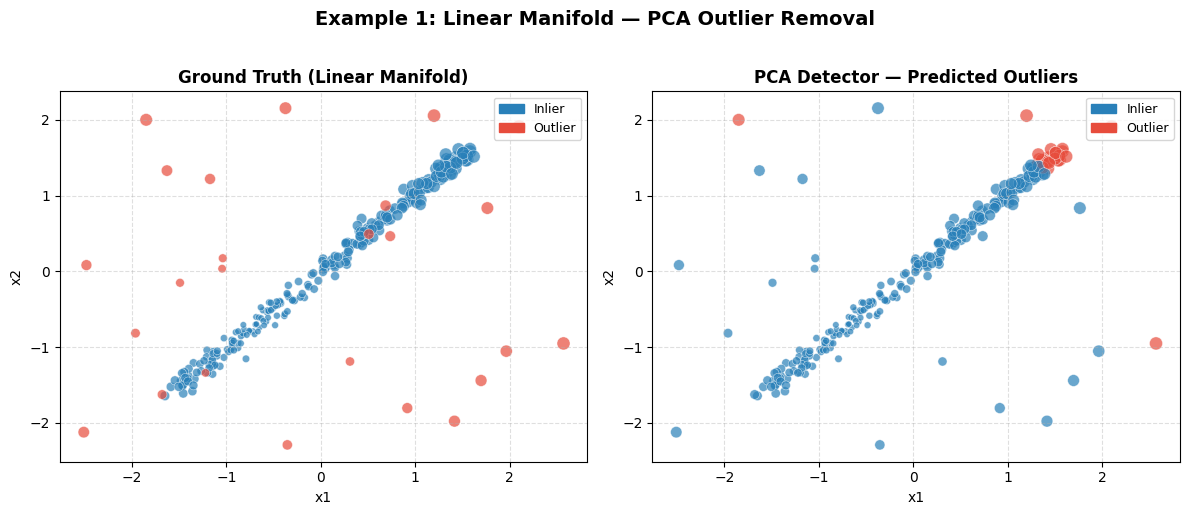

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_outliers(X_lin, y_lin_true,  'Ground Truth (Linear Manifold)', scores_pca, axes[0])
plot_outliers(X_lin, labels_pca,  'PCA Detector — Predicted Outliers', scores_pca, axes[1])

plt.suptitle('Example 1: Linear Manifold — PCA Outlier Removal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Compare: PCA vs OCSVM on Linear Manifold

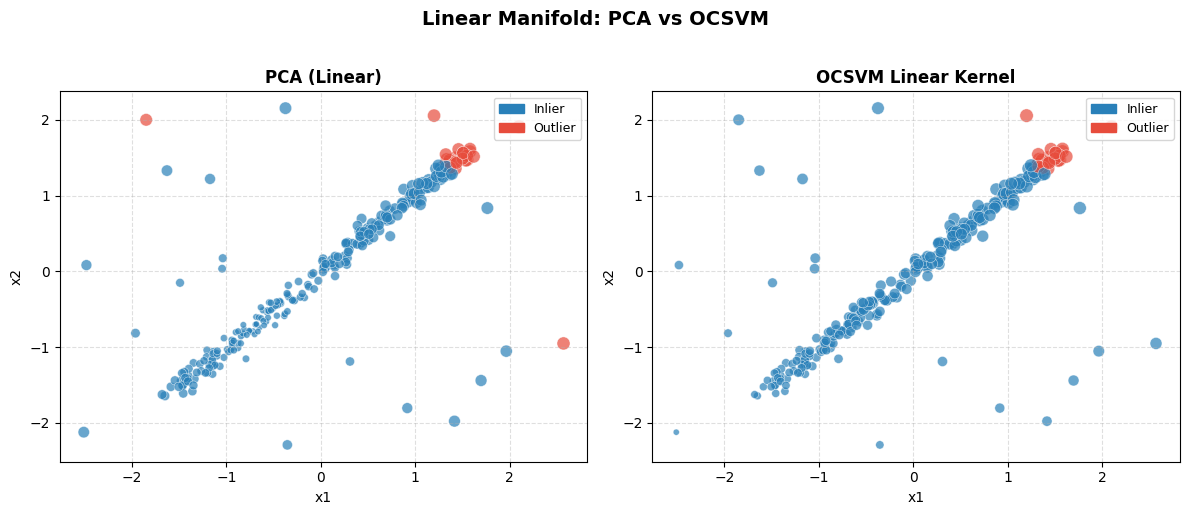

In [6]:
ocsvm_lin = OCSVM(kernel='linear', contamination=contamination)
ocsvm_lin.fit(X_lin)
labels_ocsvm_lin = ocsvm_lin.labels_
scores_ocsvm_lin = ocsvm_lin.decision_scores_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_outliers(X_lin, labels_pca,       'PCA (Linear)',          scores_pca,       axes[0])
plot_outliers(X_lin, labels_ocsvm_lin, 'OCSVM Linear Kernel',  scores_ocsvm_lin, axes[1])

plt.suptitle('Linear Manifold: PCA vs OCSVM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Example 2
## Nonlinear Manifold — Circular / Ring Structure

### Data Generation: Nonlinear (Circular) Manifold

- Inliers: points sampled on a **circle** (classic nonlinear 1D manifold in 2D)
- Outliers: scattered randomly inside and outside the ring

> PCA will fail here — it finds a linear subspace, missing the curved structure.

In [7]:
# --- Inliers: noisy circle ---
angles    = np.random.uniform(0, 2 * np.pi, n_inliers)
X_circle  = np.column_stack([
    3 * np.cos(angles) + np.random.normal(0, 0.2, n_inliers),
    3 * np.sin(angles) + np.random.normal(0, 0.2, n_inliers)
])

# --- Outliers: random points inside and far outside ---
X_out_circ = np.random.uniform(-5, 5, (n_outliers, 2))

X_circ      = np.vstack([X_circle, X_out_circ])
y_circ_true = np.array([0]*n_inliers + [1]*n_outliers)

X_circ = StandardScaler().fit_transform(X_circ)
print(f"Dataset: {len(X_circ)} points | {n_outliers} injected outliers")

Dataset: 275 points | 25 injected outliers


### Detector: LOF — Local Outlier Factor

**Why LOF works for nonlinear manifolds:**
- LOF compares the **local density** of a point to its neighbors
- It naturally adapts to curved, non-convex structures
- Does NOT assume any global shape

$$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{|N_k(p)|}$$

- LOF >> 1 means the point is less dense than its neighbors → **outlier**

In [8]:
lof_detector = LOF(n_neighbors=20, contamination=contamination)
lof_detector.fit(X_circ)

labels_lof = lof_detector.labels_
scores_lof = lof_detector.decision_scores_

print(f"LOF detected {labels_lof.sum()} outliers  (true: {n_outliers})")

LOF detected 25 outliers  (true: 25)


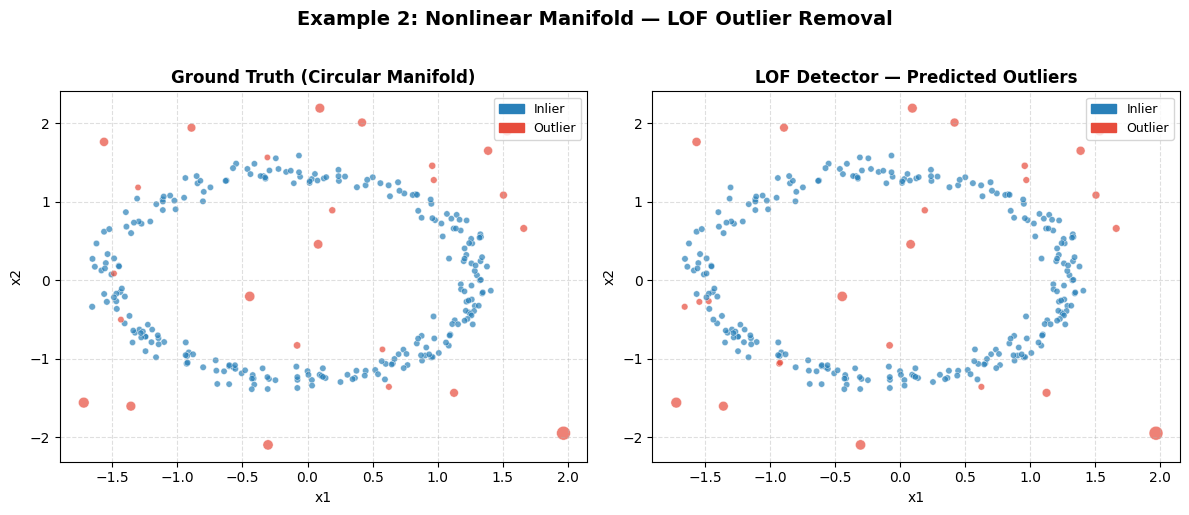

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_outliers(X_circ, y_circ_true, 'Ground Truth (Circular Manifold)', scores_lof, axes[0])
plot_outliers(X_circ, labels_lof,  'LOF Detector — Predicted Outliers', scores_lof, axes[1])

plt.suptitle('Example 2: Nonlinear Manifold — LOF Outlier Removal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Why PCA Fails on Nonlinear Manifolds

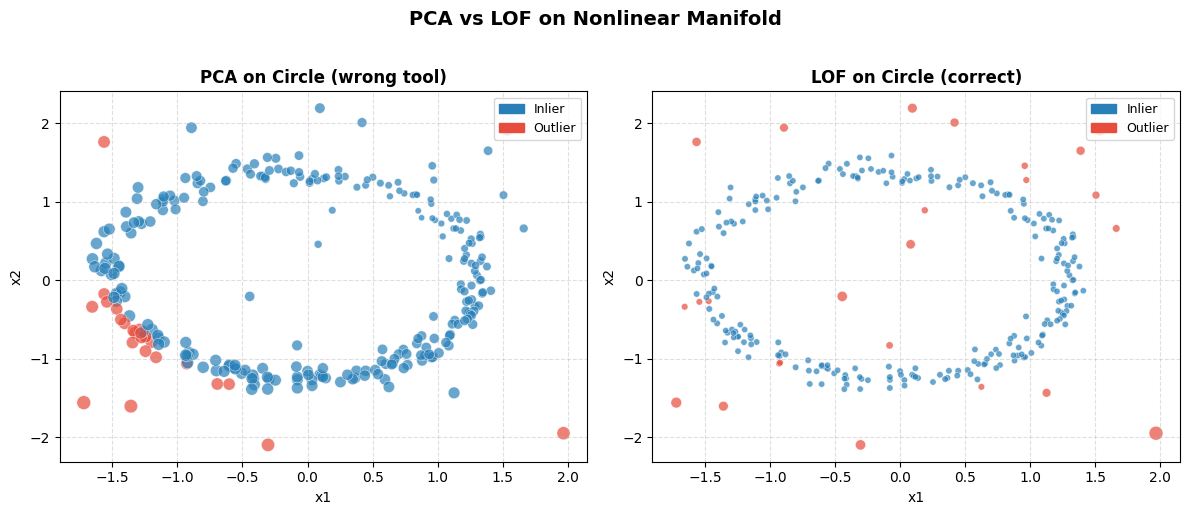

PCA mistakes inliers on the circle sides as outliers — high reconstruction error at extremes.


In [10]:
pca_on_circ = PyOD_PCA(n_components=1, contamination=contamination)
pca_on_circ.fit(X_circ)
labels_pca_circ = pca_on_circ.labels_
scores_pca_circ = pca_on_circ.decision_scores_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_outliers(X_circ, labels_pca_circ, 'PCA on Circle (wrong tool)', scores_pca_circ, axes[0])
plot_outliers(X_circ, labels_lof,      'LOF on Circle (correct)',    scores_lof,      axes[1])

plt.suptitle('PCA vs LOF on Nonlinear Manifold', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("PCA mistakes inliers on the circle sides as outliers — high reconstruction error at extremes.")

# Example 3
## Nonlinear Manifold — Half-Moon / S-Curve

An even harder case: two interleaved crescent shapes.

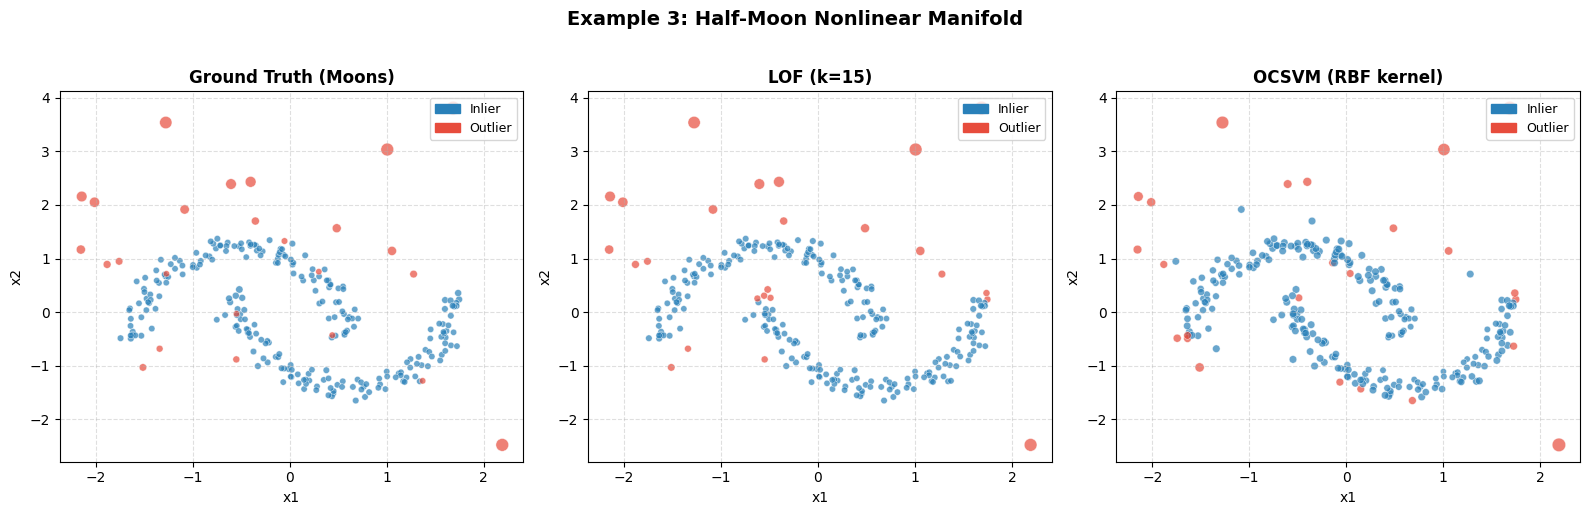

In [11]:
from sklearn.datasets import make_moons

X_moons_raw, _ = make_moons(n_samples=n_inliers, noise=0.07, random_state=42)
X_out_moon     = np.random.uniform(-1.5, 2.5, (n_outliers, 2))

X_moon      = np.vstack([X_moons_raw, X_out_moon])
y_moon_true = np.array([0]*n_inliers + [1]*n_outliers)
X_moon      = StandardScaler().fit_transform(X_moon)

# LOF
lof_moon = LOF(n_neighbors=15, contamination=contamination)
lof_moon.fit(X_moon)

# OCSVM with RBF kernel
ocsvm_rbf = OCSVM(kernel='rbf', nu=contamination, contamination=contamination)
ocsvm_rbf.fit(X_moon)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_outliers(X_moon, y_moon_true,       'Ground Truth (Moons)',          lof_moon.decision_scores_,  axes[0])
plot_outliers(X_moon, lof_moon.labels_,  'LOF (k=15)',                    lof_moon.decision_scores_,  axes[1])
plot_outliers(X_moon, ocsvm_rbf.labels_, 'OCSVM (RBF kernel)',            ocsvm_rbf.decision_scores_, axes[2])

plt.suptitle('Example 3: Half-Moon Nonlinear Manifold', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Score Distribution Analysis

Visualising the **anomaly score distributions** helps understand detector confidence and threshold setting.

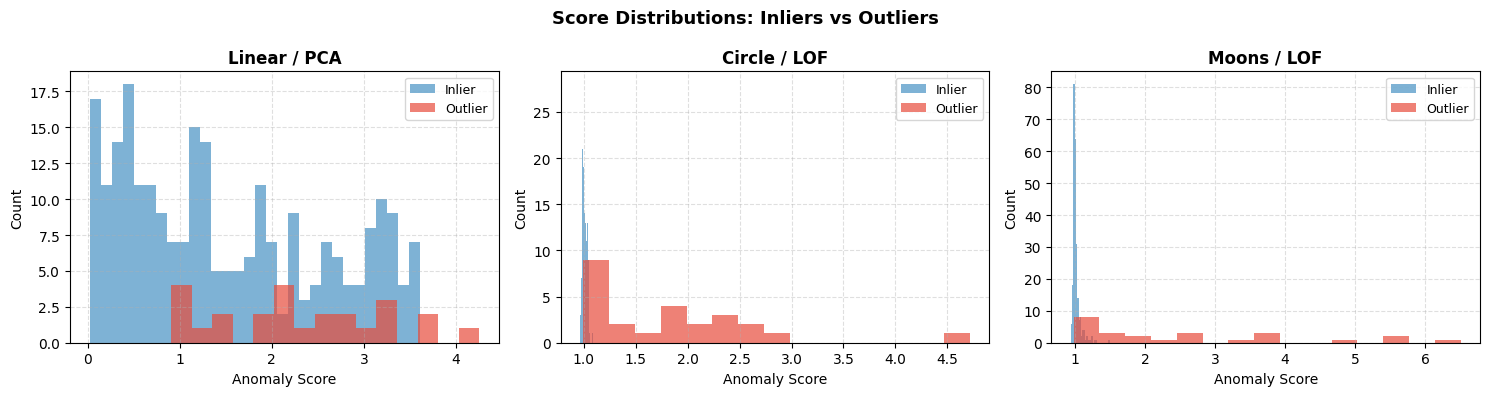

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ('Linear / PCA',    scores_pca,       y_lin_true),
    ('Circle / LOF',    scores_lof,       y_circ_true),
    ('Moons / LOF',     lof_moon.decision_scores_, y_moon_true),
]

for ax, (title, scores, truth) in zip(axes, datasets):
    ax.hist(scores[truth == 0], bins=30, alpha=0.6, color='#2980b9', label='Inlier')
    ax.hist(scores[truth == 1], bins=15, alpha=0.7, color='#e74c3c', label='Outlier')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Score Distributions: Inliers vs Outliers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary: Choosing the Right Detector

| Scenario | Manifold Shape | Recommended Detector | Reason |
|---|---|---|---|
| Correlated features | **Linear** | PCA, OCSVM (linear) | Reconstruction error along PCs |
| Curved clusters | **Nonlinear** | LOF, OCSVM (RBF) | Local density / kernel boundary |
| Interleaved shapes | **Nonlinear** | LOF, ECOD | Neighborhood-based, no shape assumption |
| Unknown structure | **Any** | LOF, ECOD | Non-parametric, robust |

### Key Takeaways
- **Never blindly apply PCA** — it assumes linearity
- **LOF** is a safe default for unknown manifold shape
- **Contamination** parameter directly controls the outlier threshold
- Always **visualise** score distributions to validate detector fit

## Privacy and redaction

### LLM-aware privacy checklist

- Remove direct identifiers where possible
- Mask quasi-identifiers in combination
- Separate access roles for raw vs processed data
- Document legal basis and retention policy
- redakto example, results from paper

### Human review for risky records

Use a human-in-the-loop pass before sharing prompts or datasets externally.

## Synthetic data discussion

Evaluate synthetic data with three axes:

- Fidelity: does it preserve relevant structure?
- Privacy: does it leak original individuals?
- Utility: does it support downstream task performance?

## Exercise direction

- Run missing-value strategies on one dataset
- Compare downstream model metrics
- Reflect on which quality checks changed model conclusions

## Legacy source mapping

- Main cleaning notebook: [old-felix/lecture-3/dsw-lecture-3-data-cleaning.ipynb](old-felix/lecture-3/dsw-lecture-3-data-cleaning.ipynb)
- Missing-value exercise notebook: [old-felix/lecture-3/missing-value-exercise.ipynb](old-felix/lecture-3/missing-value-exercise.ipynb)
- Datasheet template example: [old-felix/modelcards-datasheets/covidstate-DATASHEET.md](old-felix/modelcards-datasheets/covidstate-DATASHEET.md)